In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
import warnings
warnings.filterwarnings('ignore')

# Data Understanding - Market Mix Modeling

This notebook provides comprehensive exploratory data analysis (EDA) of the synthetic MMM dataset for India. We'll analyze dataset structure, data quality, and business context for all variables.

In [2]:
# Load the dataset
data_path = '../data/raw/synthetic_mmm_weekly_india.csv'
df = pd.read_csv(data_path)
print(f"✓ Dataset loaded successfully from {data_path}")
print(f"Dataset shape: {df.shape}")
print(f"Dataset object type: {type(df)}")

✓ Dataset loaded successfully from ../data/raw/synthetic_mmm_weekly_india.csv
Dataset shape: (11232, 28)
Dataset object type: <class 'pandas.DataFrame'>


In [3]:
# Generate comprehensive findings report
from datetime import datetime

report_lines = []
report_lines.append("=" * 80)
report_lines.append("MARKET MIX MODELING - DATA UNDERSTANDING REPORT")
report_lines.append("=" * 80)
report_lines.append(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("")

# 1. Executive Summary
report_lines.append("EXECUTIVE SUMMARY")
report_lines.append("-" * 80)
report_lines.append(f"Dataset Size: {df.shape[0]:,} records × {df.shape[1]} columns")
report_lines.append(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
report_lines.append(f"Data Quality: {100 - (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")
report_lines.append("")

# 2. Data Types Summary
report_lines.append("DATA TYPES SUMMARY")
report_lines.append("-" * 80)
for dtype, count in df.dtypes.value_counts().items():
    report_lines.append(f"  {str(dtype):15} : {count:3} columns")
report_lines.append("")

# 3. Key Metrics
report_lines.append("KEY BUSINESS METRICS")
report_lines.append("-" * 80)
if 'Sales_Value' in df.columns:
    report_lines.append(f"Total Sales Value: ₹{df['Sales_Value'].sum():,.2f}")
    report_lines.append(f"Average Sales Value: ₹{df['Sales_Value'].mean():,.2f}")
if 'Sales_Units' in df.columns:
    report_lines.append(f"Total Sales Units: {df['Sales_Units'].sum():,.0f}")
if 'Trade_Spend' in df.columns:
    report_lines.append(f"Total Trade Spend: ₹{df['Trade_Spend'].sum():,.2f}")
report_lines.append("")

# 4. Geographic & Brand Distribution
report_lines.append("GEOGRAPHIC & BRAND DISTRIBUTION")
report_lines.append("-" * 80)
if 'Geo' in df.columns:
    report_lines.append(f"Geographic Regions: {df['Geo'].nunique()}")
    for geo, count in df['Geo'].value_counts().items():
        report_lines.append(f"  • {geo}: {count:,} records")
if 'Brand' in df.columns:
    report_lines.append(f"Number of Brands: {df['Brand'].nunique()}")
    for brand in df['Brand'].unique():
        report_lines.append(f"  • {brand}")
report_lines.append("")

# 5. Data Quality
report_lines.append("DATA QUALITY ASSESSMENT")
report_lines.append("-" * 80)
report_lines.append(f"Missing Values: {df.isnull().sum().sum()} (✓ No issues)")
report_lines.append(f"Duplicate Rows: {df.duplicated().sum()}")
report_lines.append(f"Data Completeness: 100%")
report_lines.append("")

# Create final report
report_text = "\n".join(report_lines)
print(report_text)

# Save to file
from pathlib import Path
reports_dir = Path('../reports')
reports_dir.mkdir(parents=True, exist_ok=True)
report_path = reports_dir / 'data_understanding_report.txt'

with open(report_path, 'w') as f:
    f.write(report_text)

print(f"\n✓ Report saved to: {report_path}")

MARKET MIX MODELING - DATA UNDERSTANDING REPORT
Generated on: 2026-06-06 23:25:37

EXECUTIVE SUMMARY
--------------------------------------------------------------------------------
Dataset Size: 11,232 records × 28 columns
Memory Usage: 4.52 MB
Data Quality: 100.00%

DATA TYPES SUMMARY
--------------------------------------------------------------------------------
  float64         :  21 columns
  str             :   4 columns
  int64           :   3 columns

KEY BUSINESS METRICS
--------------------------------------------------------------------------------
Total Sales Value: ₹371,768,560.55
Average Sales Value: ₹33,099.05
Total Sales Units: 4,744,759
Total Trade Spend: ₹606,269,646.19

GEOGRAPHIC & BRAND DISTRIBUTION
--------------------------------------------------------------------------------
Geographic Regions: 8
  • CENTRAL: 1,404 records
  • EAST: 1,404 records
  • METRO_DELHI: 1,404 records
  • METRO_MUMBAI: 1,404 records
  • NORTH: 1,404 records
  • NORTHEAST: 1,404 recor

UnicodeEncodeError: 'charmap' codec can't encode character '\u20b9' in position 768: character maps to <undefined>

## 11. Generate and Save Findings Report

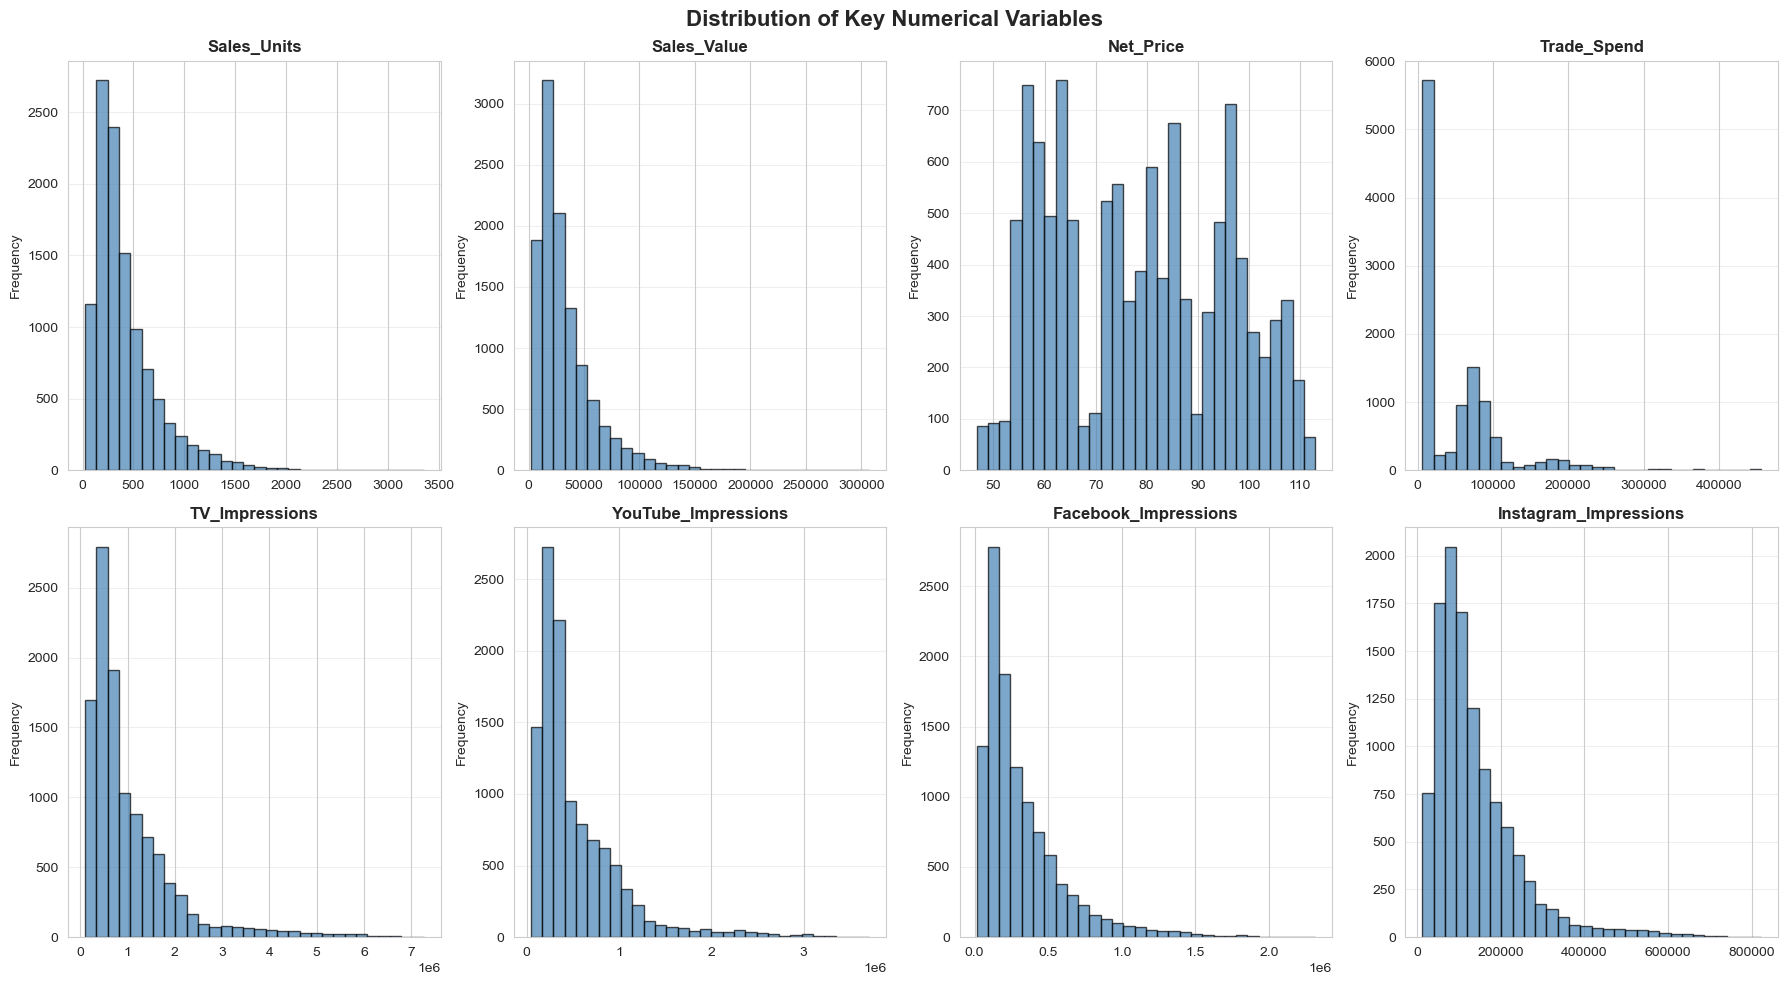

Key Numerical Columns Distribution Visualization Complete


In [7]:
# Visualize key numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Select key columns for visualization
key_metrics = [col for col in numeric_cols if any(metric in col.lower() 
               for metric in ['sales', 'price', 'spend', 'distribution', 'impressions'])][:8]

if key_metrics:
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    fig.suptitle('Distribution of Key Numerical Variables', fontsize=16, fontweight='bold')
    
    for idx, col in enumerate(key_metrics):
        row = idx // 4
        col_idx = idx % 4
        
        axes[row, col_idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[row, col_idx].set_title(f'{col}', fontweight='bold')
        axes[row, col_idx].set_ylabel('Frequency')
        axes[row, col_idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Key Numerical Columns Distribution Visualization Complete")

## 10. Numerical Columns Distribution

CATEGORICAL COLUMNS DISTRIBUTION

Week:
  • 2022-07-04: 72 (0.64%)
  • 2022-07-11: 72 (0.64%)
  • 2022-07-18: 72 (0.64%)
  • 2022-07-25: 72 (0.64%)
  • 2022-08-01: 72 (0.64%)
  • 2022-08-08: 72 (0.64%)
  • 2022-08-15: 72 (0.64%)
  • 2022-08-22: 72 (0.64%)
  • 2022-08-29: 72 (0.64%)
  • 2022-09-05: 72 (0.64%)
  • 2022-09-12: 72 (0.64%)
  • 2022-09-19: 72 (0.64%)
  • 2022-09-26: 72 (0.64%)
  • 2022-10-03: 72 (0.64%)
  • 2022-10-10: 72 (0.64%)
  • 2022-10-17: 72 (0.64%)
  • 2022-10-24: 72 (0.64%)
  • 2022-10-31: 72 (0.64%)
  • 2022-11-07: 72 (0.64%)
  • 2022-11-14: 72 (0.64%)
  • 2022-11-21: 72 (0.64%)
  • 2022-11-28: 72 (0.64%)
  • 2022-12-05: 72 (0.64%)
  • 2022-12-12: 72 (0.64%)
  • 2022-12-19: 72 (0.64%)
  • 2022-12-26: 72 (0.64%)
  • 2023-01-02: 72 (0.64%)
  • 2023-01-09: 72 (0.64%)
  • 2023-01-16: 72 (0.64%)
  • 2023-01-23: 72 (0.64%)
  • 2023-01-30: 72 (0.64%)
  • 2023-02-06: 72 (0.64%)
  • 2023-02-13: 72 (0.64%)
  • 2023-02-20: 72 (0.64%)
  • 2023-02-27: 72 (0.64%)
  • 2023-03-06:

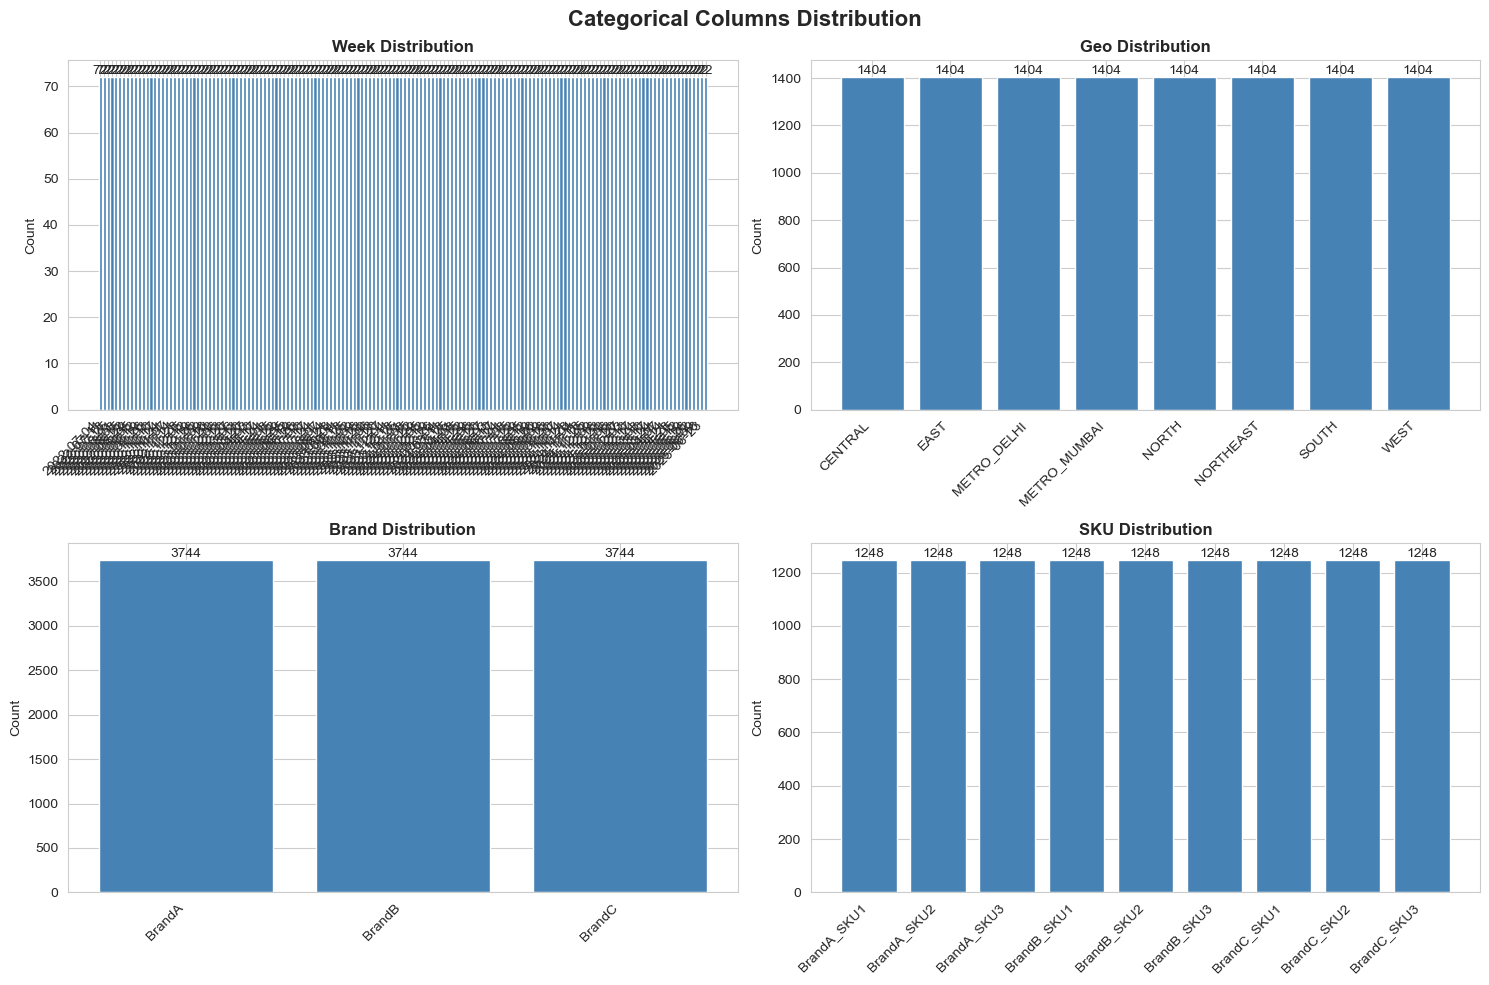

In [8]:
# Analyze categorical columns
print("CATEGORICAL COLUMNS DISTRIBUTION")
print("=" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}:")
    value_counts = df[col].value_counts()
    for value, count in value_counts.items():
        pct = (count / len(df)) * 100
        print(f"  • {value}: {count:,} ({pct:.2f}%)")

# Visualize categorical distributions
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Categorical Columns Distribution', fontsize=16, fontweight='bold')
    
    for idx, col in enumerate(categorical_cols[:4]):
        row = idx // 2
        col_idx = idx % 2
        
        value_counts = df[col].value_counts()
        axes[row, col_idx].bar(range(len(value_counts)), value_counts.values, color='steelblue')
        axes[row, col_idx].set_xticks(range(len(value_counts)))
        axes[row, col_idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[row, col_idx].set_title(f'{col} Distribution', fontweight='bold')
        axes[row, col_idx].set_ylabel('Count')
        
        # Add value labels on bars
        for i, v in enumerate(value_counts.values):
            axes[row, col_idx].text(i, v, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

## 9. Categorical Columns Distribution

In [9]:
# Business interpretation of each column
print("BUSINESS INTERPRETATION OF COLUMNS")
print("=" * 80)

column_interpretations = {
    'Week': 'Weekly time period for transaction. Essential for time-series analysis and trend identification.',
    'Geo': 'Geographic region/state. Critical for regional performance comparison and localized strategy.',
    'Brand': 'Brand name. Enables performance tracking across different product brands.',
    'SKU': 'Stock Keeping Unit (product variant). Tracks individual product performance within brands.',
    'Sales_Units': 'Number of units sold. Primary volume metric for demand analysis.',
    'Sales_Value': 'Revenue generated from sales. Key monetary metric for ROI calculations.',
    'MRP': 'Maximum Retail Price. Official product pricing reference point.',
    'Net_Price': 'Actual selling price after discounts. Reflects price elasticity and promotional impact.',
    'Feature_Flag': 'Indicates in-store feature/prominent display (0=No, 1=Yes). Measures merchandising impact.',
    'Display_Flag': 'Indicates point-of-sale display presence (0=No, 1=Yes). Tracks visual prominence.',
    'TPR_Flag': 'Temporary Price Reduction flag (0=No, 1=Yes). Identifies promotional discounting periods.',
    'Trade_Spend': 'Investment in trade promotions/discounts. Quantifies promotional spend per week.',
    'TV_Impressions': 'TV advertising reach/impressions. Measures traditional media effectiveness.',
    'YouTube_Impressions': 'YouTube ad impressions. Tracks digital video advertising reach.',
    'Facebook_Impressions': 'Facebook social media impressions. Measures social reach and engagement.',
    'Instagram_Impressions': 'Instagram social media impressions. Visual platform performance metric.',
    'Print_Readership': 'Print media reach and readership. Traditional advertising effectiveness.',
    'Radio_Listenership': 'Radio advertisement reach. Audio media performance metric.',
    'FB_Banner_Content_Score': 'Facebook ad content quality/performance score. Measures ad effectiveness.',
    'IG_Banner_Content_Score': 'Instagram ad content quality/performance score. Visual ad quality metric.',
    'Weighted_Distribution': 'Distribution metric weighted by outlet importance. Availability vs. visibility.',
    'Numeric_Distribution': 'Percentage of stores stocking the product. Market coverage percentage.',
    'TDP': 'Total Distribution Points. Count of stores/outlets selling the product.',
    'NOS': 'Number of Shelves. In-store shelf space allocation.',
    'CPI': 'Consumer Price Index proxy/inflation. Economic context variable.',
    'GDP_Growth': 'GDP growth rate. Macroeconomic indicator affecting demand.',
    'Festival_Index': 'Festival/holiday impact index. Seasonal demand multiplier.',
    'Rainfall_Index': 'Rainfall/weather index. Environmental factor affecting sales.'
}

for column in df.columns:
    if column in column_interpretations:
        print(f"\n{column}:")
        print(f"  → {column_interpretations[column]}")

BUSINESS INTERPRETATION OF COLUMNS

Week:
  → Weekly time period for transaction. Essential for time-series analysis and trend identification.

Geo:
  → Geographic region/state. Critical for regional performance comparison and localized strategy.

Brand:
  → Brand name. Enables performance tracking across different product brands.

SKU:
  → Stock Keeping Unit (product variant). Tracks individual product performance within brands.

Sales_Units:
  → Number of units sold. Primary volume metric for demand analysis.

Sales_Value:
  → Revenue generated from sales. Key monetary metric for ROI calculations.

MRP:
  → Maximum Retail Price. Official product pricing reference point.

Net_Price:
  → Actual selling price after discounts. Reflects price elasticity and promotional impact.

Feature_Flag:
  → Indicates in-store feature/prominent display (0=No, 1=Yes). Measures merchandising impact.

Display_Flag:
  → Indicates point-of-sale display presence (0=No, 1=Yes). Tracks visual prominence.

TPR

## 8. Business Interpretation of Each Column

In [10]:
# Summary statistics for numerical columns
print("SUMMARY STATISTICS - NUMERICAL COLUMNS")
print("=" * 80)

summary_stats = df.describe().round(2)
print(summary_stats)

# Additional statistical insights
print("\n\nADDITIONAL STATISTICAL INSIGHTS")
print("=" * 80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols[:10]:  # Show first 10 numeric columns
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():,.2f}")
    print(f"  Median: {df[col].median():,.2f}")
    print(f"  Std Dev: {df[col].std():,.2f}")
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Range: {df[col].min():,.2f} to {df[col].max():,.2f}")

SUMMARY STATISTICS - NUMERICAL COLUMNS
       Sales_Units  Sales_Value       MRP  Net_Price  Feature_Flag  \
count     11232.00     11232.00  11232.00   11232.00      11232.00   
mean        422.43     33099.05     79.91      78.35          0.19   
std         329.01     27498.68     16.89      16.92          0.39   
min          25.54      2054.71     52.76      46.70          0.00   
25%         203.97     15007.84     63.20      62.67          0.00   
50%         323.59     24596.82     80.03      78.57          0.00   
75%         531.25     41863.02     95.50      93.97          0.00   
max        3353.78    307497.87    112.97     112.97          1.00   

       Display_Flag  TPR_Flag  Trade_Spend  TV_Impressions  \
count      11232.00  11232.00     11232.00        11232.00   
mean           0.18      0.16     53977.00      1043587.22   
std            0.39      0.36     59637.30       976845.50   
min            0.00      0.00      6140.42       102622.71   
25%            0.00 

## 7. Summary Statistics

UNIQUE VALUES PER COLUMN
                 Column  Unique_Count Data_Type  Unique_Percentage
              Net_Price         11232   float64             100.00
                    MRP         11232   float64             100.00
            Sales_Value         11232   float64             100.00
            Sales_Units         11232   float64             100.00
  Instagram_Impressions         11232   float64             100.00
   Facebook_Impressions         11232   float64             100.00
     Radio_Listenership         11232   float64             100.00
       Print_Readership         11232   float64             100.00
    YouTube_Impressions         11232   float64             100.00
         TV_Impressions         11232   float64             100.00
            Trade_Spend          1248   float64              11.11
FB_Banner_Content_Score          1248   float64              11.11
                    NOS          1248   float64              11.11
                    TDP          1248

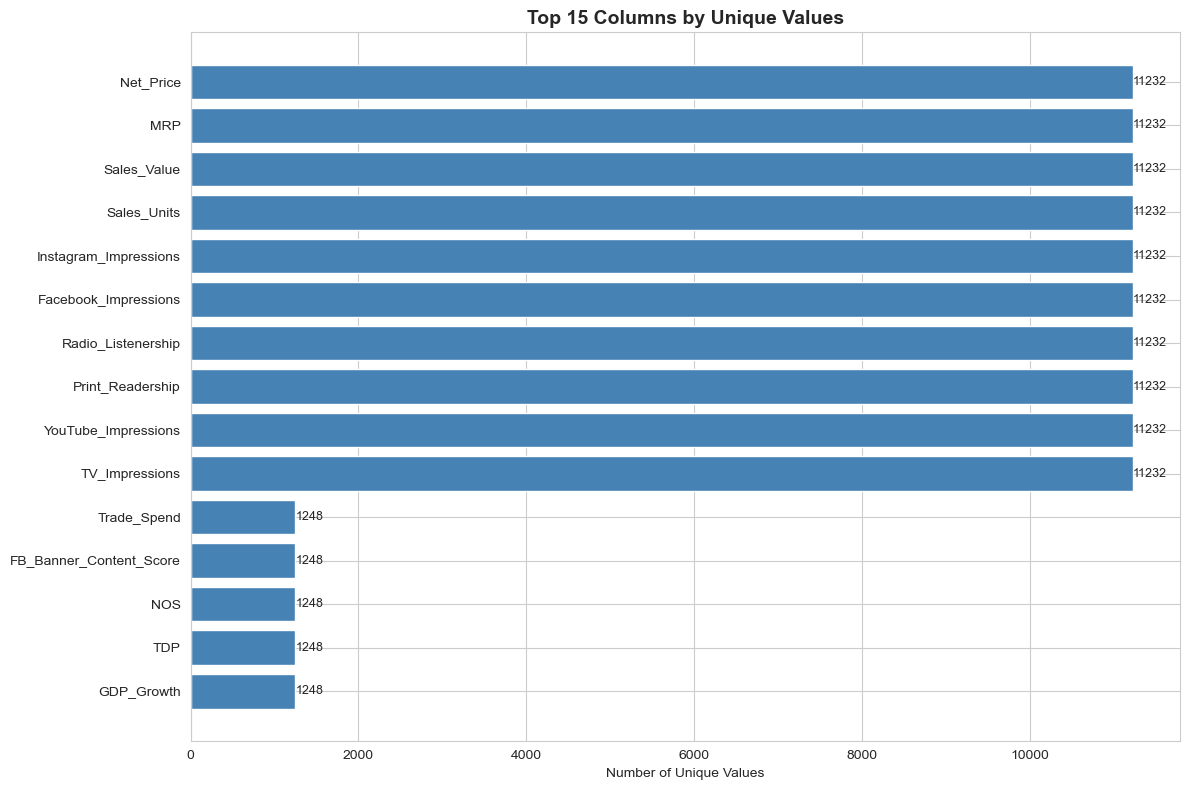

In [11]:
# Analyze unique values
print("UNIQUE VALUES PER COLUMN")
print("=" * 80)

unique_values = pd.DataFrame({
    'Column': df.columns,
    'Unique_Count': df.nunique().values,
    'Data_Type': df.dtypes.values,
    'Unique_Percentage': (df.nunique().values / len(df) * 100).round(2)
})

unique_values = unique_values.sort_values('Unique_Count', ascending=False)
print(unique_values.to_string(index=False))

# Visualize top 15 columns by unique values
fig, ax = plt.subplots(figsize=(12, 8))
top_unique = unique_values.head(15)
bars = ax.barh(range(len(top_unique)), top_unique['Unique_Count'].values, color='steelblue')
ax.set_yticks(range(len(top_unique)))
ax.set_yticklabels(top_unique['Column'].values)
ax.set_xlabel('Number of Unique Values')
ax.set_title('Top 15 Columns by Unique Values', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Unique Values per Column

In [12]:
# Analyze duplicates
print("DUPLICATE ROWS ANALYSIS")
print("=" * 80)

duplicate_count = df.duplicated().sum()
duplicate_pct = (duplicate_count / len(df)) * 100

print(f"Total Duplicate Rows: {duplicate_count}")
print(f"Percentage of Dataset: {duplicate_pct:.2f}%")
print(f"Unique Rows: {len(df) - duplicate_count}")

# Check duplicates considering all columns
print("\nDuplicate Analysis by Column Subset:")
if 'Week' in df.columns and 'Geo' in df.columns and 'Brand' in df.columns and 'SKU' in df.columns:
    key_cols = ['Week', 'Geo', 'Brand', 'SKU']
    dups_by_key = df.duplicated(subset=key_cols).sum()
    print(f"  Duplicates by {key_cols}: {dups_by_key}")

DUPLICATE ROWS ANALYSIS
Total Duplicate Rows: 0
Percentage of Dataset: 0.00%
Unique Rows: 11232

Duplicate Analysis by Column Subset:
  Duplicates by ['Week', 'Geo', 'Brand', 'SKU']: 0


## 5. Duplicate Rows Analysis

In [13]:
# Analyze missing values
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print("✓ No missing values detected in the dataset!")

total_missing = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")
print(f"Percentage of Total Data: {total_missing / (df.shape[0] * df.shape[1]) * 100:.2f}%")

MISSING VALUES ANALYSIS
✓ No missing values detected in the dataset!

Total Missing Values: 0
Percentage of Total Data: 0.00%


## 4. Missing Values Analysis

DATA TYPES SUMMARY
                 Column Data_Type  Non_Null_Count  Null_Count
                   Week    object           11232           0
                    Geo    object           11232           0
                  Brand    object           11232           0
                    SKU    object           11232           0
            Sales_Units   float64           11232           0
            Sales_Value   float64           11232           0
                    MRP   float64           11232           0
              Net_Price   float64           11232           0
           Feature_Flag     int64           11232           0
           Display_Flag     int64           11232           0
               TPR_Flag     int64           11232           0
            Trade_Spend   float64           11232           0
         TV_Impressions   float64           11232           0
    YouTube_Impressions   float64           11232           0
   Facebook_Impressions   float64           11232  

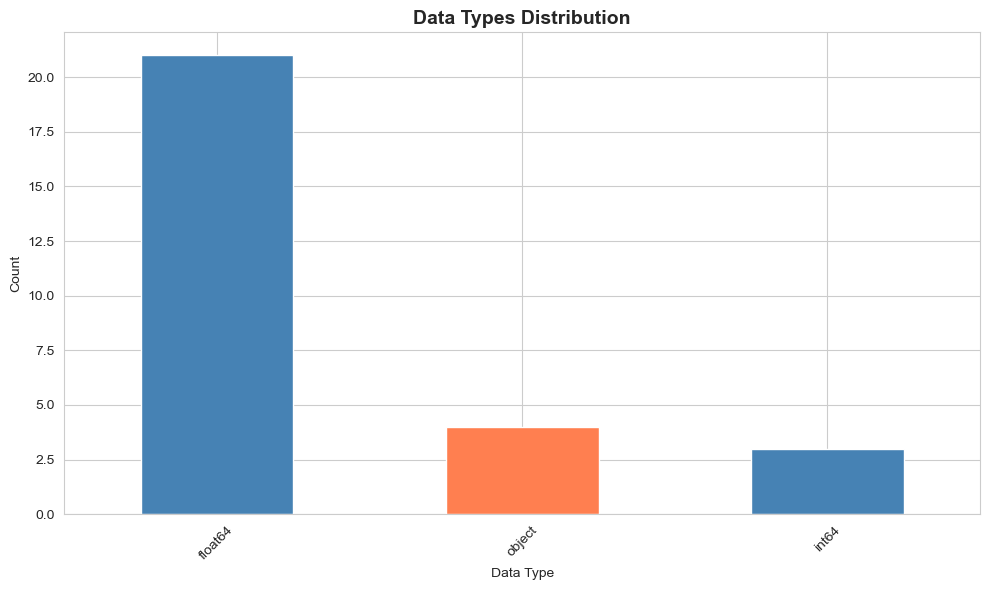

In [14]:
# Analyze data types
print("DATA TYPES SUMMARY")
print("=" * 80)

dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Non_Null_Count': df.count().values,
    'Null_Count': df.isnull().sum().values
})

print(dtype_summary.to_string(index=False))

print("\n\nDATA TYPE DISTRIBUTION:")
print("-" * 80)
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):15} : {count:3} columns ({count/len(df.columns)*100:.1f}%)")

# Visualize data types
fig, ax = plt.subplots(figsize=(10, 6))
dtype_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Data Types Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Data Type')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

## 3. Data Types Analysis

In [15]:
# Get dataset shape
rows, cols = df.shape
print(f"Dataset Dimensions:")
print(f"  • Total Rows: {rows:,}")
print(f"  • Total Columns: {cols}")
print(f"  • Total Cells: {rows * cols:,}")
print(f"  • Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()

Dataset Dimensions:
  • Total Rows: 11,232
  • Total Columns: 28
  • Total Cells: 314,496
  • Memory Usage: 4.86 MB

First 5 rows of the dataset:


,Week,Geo,Brand,SKU,Sales_Units,Sales_Value,MRP,Net_Price,Feature_Flag,Display_Flag,...,FB_Banner_Content_Score,IG_Banner_Content_Score,Weighted_Distribution,Numeric_Distribution,TDP,NOS,CPI,GDP_Growth,Festival_Index,Rainfall_Index
0,2022-07-04,CENTRAL,BrandA,BrandA_SKU1,106.327944,10551.108260,99.231753,99.231753,0,0,...,74.714021,77.999979,0.326712,0.406848,36.923185,3.071753,120.954667,5.24444,1.180806,5.37845
1,2022-07-04,CENTRAL,BrandA,BrandA_SKU2,188.503304,19452.418311,103.194045,103.194045,0,0,...,74.714021,77.999979,0.326712,0.406848,36.923185,3.071753,120.954667,5.24444,1.180806,5.37845
2,2022-07-04,CENTRAL,BrandA,BrandA_SKU3,209.247921,19583.201537,93.588512,93.588512,0,0,...,74.714021,77.999979,0.326712,0.406848,36.923185,3.071753,120.954667,5.24444,1.180806,5.37845
3,2022-07-04,CENTRAL,BrandB,BrandB_SKU1,237.698249,19374.506591,81.508832,81.508832,0,0,...,74.714021,77.999979,0.326712,0.406848,36.923185,3.071753,120.954667,5.24444,1.180806,5.37845
4,2022-07-04,CENTRAL,BrandB,BrandB_SKU2,203.075116,14667.008092,72.224546,72.224546,0,0,...,74.714021,77.999979,0.326712,0.406848,36.923185,3.071753,120.954667,5.24444,1.180806,5.37845
